# Stage 16 — Which choices move the map?

The Introduction ends with a question: which choices change the answer, and by how much? This stage answers it with one comparison. Every choice we tested is run against the **main map** (D8 connectivity at 25 m or 100 m, DEA 2020 pressure averaged over each named system, slope multiplier 0.5 to 1) and scored with one measure, the **rank correlation over the mapped karst cells**: 1 means the same ordering of cells, lower means a bigger change.

Choices are grouped under the three tests of the project, plus the other judgement calls:

| Group | Choices |
|---|---|
| **Scale** | Routing on a 2 m DEM (Mole Creek only); the 100 m grid against 25 m (Mole Creek only) |
| **Data** | LIST 2021 land use instead of DEA |
| **Method** | S and C summed; all four summed; six-input weighted sums |
| **Slope** | Ceiling of 10 degrees; COP's Scenario 2 direction |
| **Other** | No catchment averaging of pressure; connectivity weighted double |

Details of each test are in Stages 8, 9, 13 and 14; this stage only brings the numbers together on one measure.

In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from karst import (add_karst_susceptibility, add_connectivity, add_connectivity_d8, rasterize_max,
                   in_mole_creek_focus, mole_creek_focus_mask, aggregate_pressure_by_system)
from hydro import slope_degrees, slope_risk_multiplier, score_watercourses
from landuse import fetch_landuse_pressure
from landuse_list import MATRIX, load_list_landuse, pressure_raster
from structures import weighted_sum, build_inputs, W_EQUAL, W_EXPERT

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"
LIST_2021 = inpath / "LIST_LAND_USE_2021_STATEWIDE" / "list_land_use_2021_statewide.shp"
LIST_TOP = float(max(MATRIX.values()))
COP_EDGES = [float(np.degrees(np.arctan(p / 100))) for p in (8, 31, 76)]

def cop_scenario2(slope_deg):
    """COP Scenario 2: flatter = higher, four classes at 8%, 31%, 76%, scaled 1 down to 0.5."""
    cls = np.digitize(np.nan_to_num(slope_deg), COP_EDGES)
    return np.where(np.isnan(slope_deg), 1.0, np.array([1.0, 5 / 6, 4 / 6, 0.5])[cls])

def variants(S, C, P_main, m, extras):
    """Risk rasters for every choice. S, C, P in 0-1, m the slope multiplier; `extras` carries the alternatives."""
    slope_in = (m - 0.5) / 0.5
    gate = S > 0
    out = {
        "main": S * C * P_main * m,
        "Data: LIST 2021 land use": S * C * extras["P_list"] * m,
        "Method: S and C summed (1:1)": (S + C) / 2 * P_main * m,
        "Method: all four summed (equal)": np.where(gate, (S + C + P_main + slope_in) / 4, 0.0),
        "Method: six-input weighted sum (equal)": weighted_sum(extras["X"], W_EQUAL) * P_main,
        "Method: six-input weighted sum (expert)": weighted_sum(extras["X"], W_EXPERT) * P_main,
        "Slope: ceiling 10 degrees": S * C * P_main * slope_risk_multiplier(extras["slope_deg"], ref_deg=10),
        "Slope: COP Scenario 2 (flatter = higher)": S * C * P_main * cop_scenario2(extras["slope_deg"]),
        "Other: no catchment averaging of pressure": S * C * extras["P_raw"] * m,
        "Other: connectivity weighted double": S * C ** 2 * P_main * m,
    }
    if "C_2m" in extras:
        out["Scale: routing on a 2 m DEM"] = S * extras["C_2m"] * P_main * m
    return out

def rank_corr(risks, karst_mask):
    base = risks["main"]
    rows = {}
    for name, r in risks.items():
        if name == "main":
            continue
        ok = karst_mask & np.isfinite(base) & np.isfinite(r)
        rows[name] = spearmanr(base[ok], r[ok])[0]
    return rows

## 16.1 Mole Creek (25 m)

In [2]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_mc_EPSG7855.tif") as src:
    conn_mc = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    p2020 = src.read(1).astype(float); p_nodata = src.nodata
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata; transform = src.transform; shape = dem.shape; cell = abs(src.transform.a); bounds = src.bounds

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid = (dem != dem_nodata) & focus & (p2020 != p_nodata)
karst_cells = valid & (intensity > 0)

slope_deg = slope_degrees(dem, dem_nodata, cell)
m_main = slope_risk_multiplier(slope_deg)
S = intensity / 4.0
C = conn_mc / 3.0
eff2020 = aggregate_pressure_by_system(karst_mc, p2020, transform, p_nodata)

lu = load_list_landuse(LIST_2021, "EPSG:7855", bounds_target=tuple(bounds))
p_list = pressure_raster(lu, MATRIX, shape, transform).astype(float)
eff_list = aggregate_pressure_by_system(karst_mc, p_list, transform, -1)
P_list = np.where(eff_list >= 0, eff_list / LIST_TOP, np.nan)

# six-input weighted sum inputs
wc = gpd.read_file(outpath / "watercourses_tas_EPSG7855.gpkg")
wc = score_watercourses(wc[wc["HYDLNTY1"] == "Watercourse"] if "HYDLNTY1" in wc.columns else wc)
mc_b = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg").total_bounds
wc_mc = wc.cx[mc_b[0]:mc_b[2], mc_b[1]:mc_b[3]]
karst_all = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp")
rain_range = (karst_all.loc[karst_all["KCATEGORY"].isin(list("ABCD")), "KAVRAIN"].min(), karst_all.loc[karst_all["KCATEGORY"].isin(list("ABCD")), "KAVRAIN"].max())
X = build_inputs(karst_mc, shape, transform, wc_mc, slope_deg, rain_range)

# routing on the 2 m DEM
k2 = karst_mc.copy()
add_connectivity_d8(k2, outpath / "karst_upstream_connectivity_counts_core_mc_2m_EPSG7855_jenks5.csv", scheme="decades")
C_2m = rasterize_max(k2, "connectivity", shape, transform, dtype="float32").astype(float) / 3.0

extras = {"P_list": P_list, "X": X, "slope_deg": slope_deg, "P_raw": p2020 / 3.0, "C_2m": C_2m}
risks = {k: np.where(valid, v, np.nan) for k, v in variants(S, C, eff2020 / 3.0, m_main, extras).items()}

# the 100 m statewide run, resampled to this grid (as in Stage 8)
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    coarse = np.full(shape, src.nodata, dtype="float32")
    reproject(rasterio.band(src, 1), coarse, src_transform=src.transform, src_crs=src.crs, dst_transform=transform,
              dst_crs=src.crs, resampling=Resampling.nearest, src_nodata=src.nodata, dst_nodata=src.nodata)
    nd = src.nodata
risks["Scale: 100 m grid instead of 25 m"] = np.where(valid & (coarse != nd), coarse, np.nan)

corr_mc = rank_corr(risks, karst_cells)
print(f"Mole Creek: {int((karst_cells & np.isfinite(risks['main'])).sum()):,} karst cells")
print(pd.Series(corr_mc).round(3).sort_values().to_string())

Mole Creek: 412,504 karst cells
Method: six-input weighted sum (expert)      0.179
Other: no catchment averaging of pressure    0.301
Method: six-input weighted sum (equal)       0.376
Slope: COP Scenario 2 (flatter = higher)     0.610
Scale: 100 m grid instead of 25 m            0.829
Method: S and C summed (1:1)                 0.898
Method: all four summed (equal)              0.935
Other: connectivity weighted double          0.972
Slope: ceiling 10 degrees                    0.976
Scale: routing on a 2 m DEM                  0.986
Data: LIST 2021 land use                     0.991


## 16.2 Statewide (100 m)

In [3]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
tmpl = outpath / "dem_tas_100m_EPSG7855.tif"
with rasterio.open(tmpl) as src:
    tdem = src.read(1).astype(float); tnodata = src.nodata; ttransform = src.transform; tshape = tdem.shape
    land, _ = mask(src, tasmania.geometry, crop=False, nodata=tnodata)
tvalid_land = land[0] != tnodata

karst_tas = gpd.read_file(outpath / "karst_tas_EPSG7855.gpkg")
add_karst_susceptibility(karst_tas); add_connectivity(karst_tas)
add_connectivity_d8(karst_tas, outpath / "karst_upstream_connectivity_counts_tas_100m_EPSG7855.csv", scheme="decades")
t_int = rasterize_max(karst_tas, "karst_intensity", tshape, ttransform).astype(float)
t_conn = rasterize_max(karst_tas, "connectivity", tshape, ttransform, dtype="float32").astype(float)
tS, tC = t_int / 4.0, t_conn / 3.0

bbox = tasmania.to_crs("EPSG:4326").total_bounds.tolist()
cache = inpath / "DEA_Land_Cover_Cache"
tp2020 = fetch_landuse_pressure(bbox, 2020, tmpl, target_crs="EPSG:7855", cache_dir=cache).astype(float)
tvalid = tvalid_land & (tp2020 != 255)
teff2020 = aggregate_pressure_by_system(karst_tas, tp2020, ttransform, 255)
lu_t = load_list_landuse(LIST_2021, "EPSG:7855")
tp_list = pressure_raster(lu_t, MATRIX, tshape, ttransform).astype(float)
teff_list = aggregate_pressure_by_system(karst_tas, tp_list, ttransform, -1)
tP_list = np.where(teff_list >= 0, teff_list / LIST_TOP, np.nan)

tslope = slope_degrees(tdem, tnodata, abs(ttransform.a))
tm = slope_risk_multiplier(tslope)
rain_range_t = (karst_tas.loc[karst_tas["karst_intensity"] > 0, "KAVRAIN"].min(), karst_tas.loc[karst_tas["karst_intensity"] > 0, "KAVRAIN"].max())
TX = build_inputs(karst_tas, tshape, ttransform, wc, tslope, rain_range_t)

textras = {"P_list": tP_list, "X": TX, "slope_deg": tslope, "P_raw": tp2020 / 3.0}
trisks = {k: np.where(tvalid, v, np.nan) for k, v in variants(tS, tC, teff2020 / 3.0, tm, textras).items()}
corr_tas = rank_corr(trisks, tvalid & (t_int > 0))
print(f"Tasmania: {int((tvalid & (t_int > 0) & np.isfinite(trisks['main'])).sum()):,} karst cells")
print(pd.Series(corr_tas).round(3).sort_values().to_string())

Tasmania: 410,007 karst cells
Method: six-input weighted sum (equal)       0.509
Method: six-input weighted sum (expert)      0.727
Other: no catchment averaging of pressure    0.829
Data: LIST 2021 land use                     0.849
Slope: COP Scenario 2 (flatter = higher)     0.869
Method: all four summed (equal)              0.885
Method: S and C summed (1:1)                 0.929
Slope: ceiling 10 degrees                    0.965
Other: connectivity weighted double          0.968


## 16.3 The chart

                                           Mole Creek (25 m)  Tasmania (100 m)   group                              choice
Method: six-input weighted sum (expert)                0.179             0.727  Method     six-input weighted sum (expert)
Other: no catchment averaging of pressure              0.301             0.829   Other  no catchment averaging of pressure
Method: six-input weighted sum (equal)                 0.376             0.509  Method      six-input weighted sum (equal)
Slope: COP Scenario 2 (flatter = higher)               0.610             0.869   Slope   COP Scenario 2 (flatter = higher)
Scale: 100 m grid instead of 25 m                      0.829               NaN   Scale          100 m grid instead of 25 m
Data: LIST 2021 land use                               0.991             0.849    Data                  LIST 2021 land use
Method: all four summed (equal)                        0.935             0.885  Method             all four summed (equal)
Method: S and C 

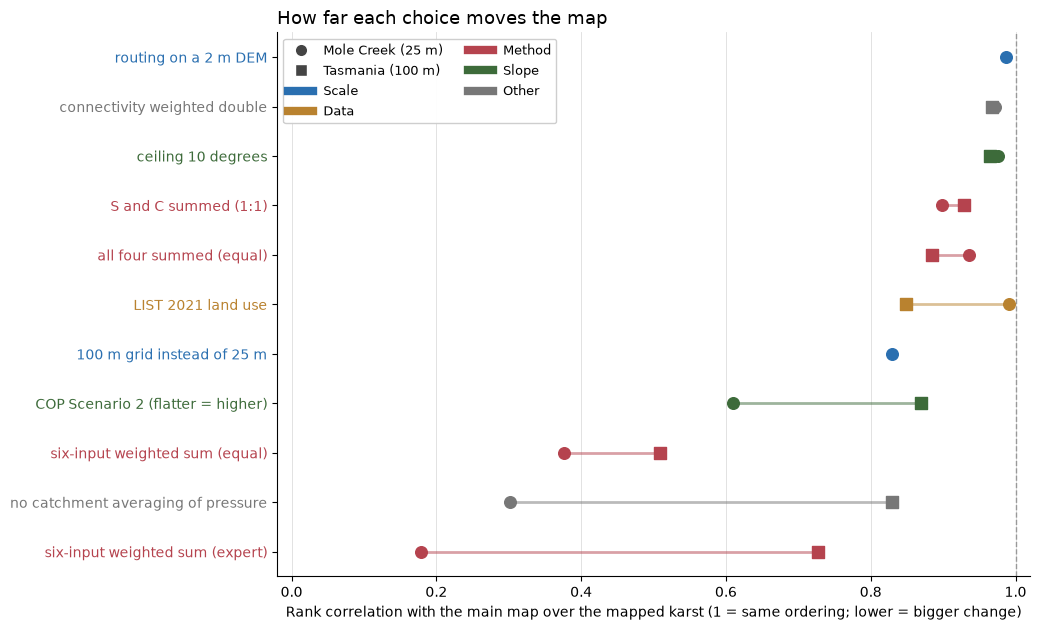

In [4]:
table = pd.DataFrame({"Mole Creek (25 m)": pd.Series(corr_mc), "Tasmania (100 m)": pd.Series(corr_tas)})
table["group"] = [n.split(":")[0] for n in table.index]
table["choice"] = [n.split(": ", 1)[1] for n in table.index]
table["sort"] = table[["Mole Creek (25 m)", "Tasmania (100 m)"]].min(axis=1)
table = table.sort_values("sort")
table.drop(columns="sort").round(3).to_csv(outpath / "stage16_choices_rank_correlation.csv")
print(table.drop(columns=["sort"]).round(3).to_string())

GROUP_COLOURS = {"Scale": "#2a6fb0", "Data": "#b9822f", "Method": "#b5434e", "Slope": "#3d6b3a", "Other": "#777777"}
fig, ax = plt.subplots(figsize=(10.5, 6.4))
ypos = np.arange(len(table))
for y, (_, row) in zip(ypos, table.iterrows()):
    colour = GROUP_COLOURS[row["group"]]
    a, b = row["Mole Creek (25 m)"], row["Tasmania (100 m)"]
    if np.isfinite(a) and np.isfinite(b):
        ax.plot([a, b], [y, y], color=colour, lw=2, alpha=0.5, zorder=1)
    if np.isfinite(a):
        ax.scatter(a, y, s=70, color=colour, marker="o", zorder=3)
    if np.isfinite(b):
        ax.scatter(b, y, s=70, color=colour, marker="s", zorder=3)
ax.set_yticks(ypos)
ax.set_yticklabels([f"{r['choice']}" for _, r in table.iterrows()], fontsize=10)
for tick, (_, row) in zip(ax.get_yticklabels(), table.iterrows()):
    tick.set_color(GROUP_COLOURS[row["group"]])
low = float(np.floor(min(0.0, table[['Mole Creek (25 m)', 'Tasmania (100 m)']].min().min()) * 10) / 10)
ax.set_xlim(low - 0.02, 1.02)
ax.axvline(1.0, color="#999999", lw=1, ls="--")
if low < 0:
    ax.axvline(0.0, color="#bbbbbb", lw=1)
ax.set_xlabel("Rank correlation with the main map over the mapped karst (1 = same ordering; lower = bigger change)", fontsize=10)
ax.grid(axis="x", color="#dddddd", lw=0.6)
ax.set_axisbelow(True)
from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker="o", color="w", markerfacecolor="#444444", markersize=9, label="Mole Creek (25 m)"),
          Line2D([0], [0], marker="s", color="w", markerfacecolor="#444444", markersize=9, label="Tasmania (100 m)")]
legend += [Line2D([0], [0], color=c, lw=6, label=g) for g, c in GROUP_COLOURS.items()]
ax.legend(handles=legend, loc="upper left", fontsize=9, framealpha=0.95, ncol=2)
ax.set_title("How far each choice moves the map", fontsize=13, loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.tight_layout()
fig.savefig(Path("..") / "figures" / "choices_that_matter.png", dpi=200, bbox_inches="tight")
plt.show()

**Result:** most choices leave the ordering of the karst nearly unchanged, and a few change it a lot.

- **Little change** (rank correlation 0.97 or above): routing on a 2 m DEM (0.99 at Mole Creek), the slope ceiling (0.98 at Mole Creek, 0.97 statewide), doubling the connectivity weight (0.97 at both) and, at Mole Creek only, LIST land use (0.99). The ceiling moves the level of risk more than the pattern.
- **Moderate** (0.83 to 0.94): the 100 m grid against 25 m at Mole Creek (0.83), summing the ingredients instead of multiplying them (0.90 to 0.94 at Mole Creek, 0.89 to 0.93 statewide), and, statewide only, LIST land use (0.85), COP's Scenario 2 slope direction (0.87) and skipping the catchment averaging of pressure (0.83).
- **Large** (below 0.65 at Mole Creek): the six-input weighted sums (0.18 and 0.38 at Mole Creek, 0.73 and 0.51 statewide), skipping the catchment averaging of pressure at Mole Creek (0.30) and COP's Scenario 2 slope direction at Mole Creek (0.61; 0.87 statewide).

The scale test (routing resolution) changes the map little. The land-cover year is not tested here: it is a change to track on the final map, not a choice (Stage 9 shows the pattern stays stable year to year while the level moves). The structural choices matter most: how pressure is averaged over a system, and which ingredients are combined and how. The data choice matters least at Mole Creek and moderately statewide. Mole Creek moves more than the state under several choices (slope direction, pressure averaging, weighted sums) because it is a small, closely mapped area where one or two systems set the ordering.